**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 01. Probability Distributions in Numerics
This notebook provides a tour of some of the 42+ univariate probability distributions available in Numerics.

## What You'll Learn

- Creating and parameterizing distributions
- Computing PDF, CDF, and quantiles
- Statistical properties (mean, variance, skewness, kurtosis)
- When to use each distribution
- Generating random samples from a distribution

## Setup

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load Numerics DLL (modify path as needed)
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

# Import commonly used distributions
from Numerics.Distributions import Normal, LogNormal, Uniform, Triangular, GammaDistribution, Weibull, GeneralizedExtremeValue, Poisson, Binomial, Pert, ParameterEstimationMethod
from Numerics.Sampling import LatinHypercube 

print("✓ Setup complete")

✓ Setup complete


## Basic Example
Recall the basic example we started in notebook 00 with the Normal distribution. We will return to that to compute the CDF, PDF, and quantiles.

### Normal Distribution

The Normal (Gaussian) distribution is the most widely used continuous distribution. It arises naturally from the Central Limit Theorem, which states that the sum of many independent random variables tends toward a Normal distribution regardless of the underlying distributions. In Numerics, the Normal distribution is parameterized by its mean $\mu$ and standard deviation $\sigma$.

#### Mathematical Definition

Probability Density Function (PDF):

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right), \quad -\infty < x < \infty
$$

Cumulative Distribution Function (CDF):

$$
F(x) = \Phi\!\left(\frac{x - \mu}{\sigma}\right) = \frac{1}{2}\left[1 + \text{erf}\!\left(\frac{x - \mu}{\sigma\sqrt{2}}\right)\right]
$$

where $\Phi(\cdot)$ is the standard Normal CDF and $\text{erf}(\cdot)$ is the error function.

Moments:

| Property | Formula |
|----------|---------|
| Mean | $E[X] = \mu$ |
| Variance | $\text{Var}(X) = \sigma^2$ |
| Skewness | $\gamma_1 = 0$ |
| Kurtosis | $\kappa = 3$ |

**When to use:** Symmetric data, many natural phenomena, Central Limit Theorem applications [[1]](#1)

**Parameters:** $\mu$ (mean), $\sigma$ (standard deviation)

Mean: 100.0
Standard Deviation: 15.0
Variance: 225.0
Skewness: 0.0
Kurtosis: 3.0
Minimum: -inf
Maximum: inf
5th Percentile: 75.32719559572791
Median: 100.0
95th Percentile: 124.67280440427207


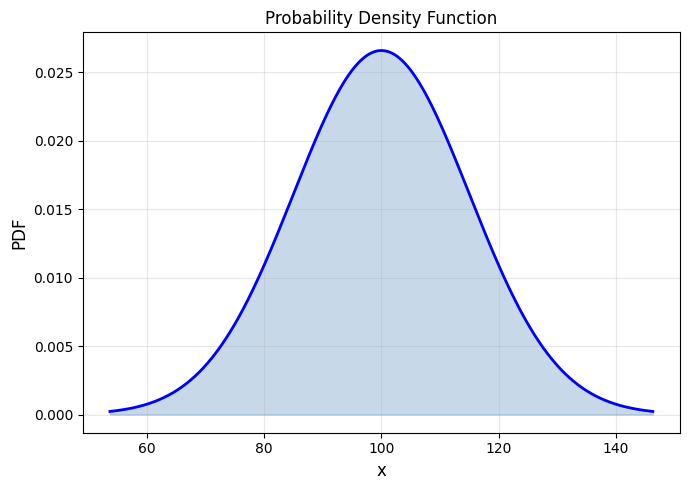

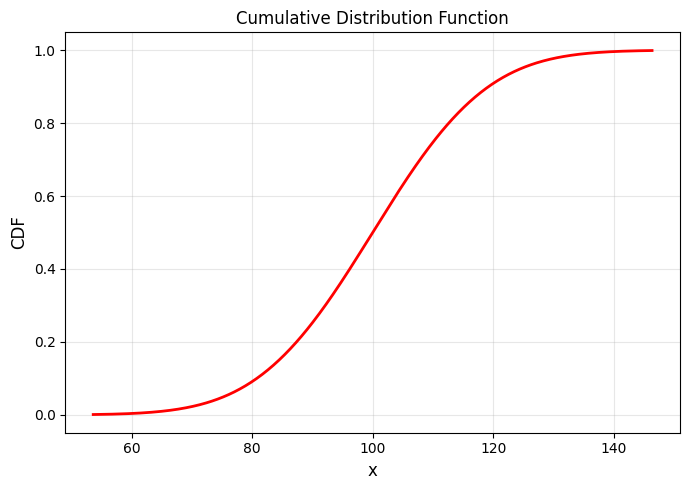

In [2]:
## Create Normal distribution -- Normal(mean=100, stddev=15)
normal = Normal(100, 15)

## Get statistical properties
print(f"Mean: {normal.Mean}")
print(f"Standard Deviation: {normal.StandardDeviation}")
print(f"Variance: {normal.Variance}")
print(f"Skewness: {normal.Skewness}")
print(f"Kurtosis: {normal.Kurtosis}")
print(f"Minimum: {normal.Minimum}")
print(f"Maximum: {normal.Maximum}")
print(f"5th Percentile: {normal.InverseCDF(0.05)}")
print(f"Median: {normal.InverseCDF(0.5)}")
print(f"95th Percentile: {normal.InverseCDF(0.95)}")

## Plotting
# Define range for x values using 0.1% to 99.9% quantiles
x_min = normal.InverseCDF(0.001)
x_max = normal.InverseCDF(0.999)
x = np.linspace(x_min, x_max, 500)

# Compute PDF and CDF values
pdf = [normal.PDF(xi) for xi in x]
cdf = [normal.CDF(xi) for xi in x]

# PDF plot
plt.figure(figsize=(7, 5))
ax1 = plt.gca() 
# !! The line below is the most important, everything else is just formatting to make it pretty!!
ax1.plot(x, pdf, 'b-', linewidth=2) 
ax1.fill_between(x, pdf, alpha=0.3, color='steelblue')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('PDF', fontsize=12)
ax1.set_title('Probability Density Function', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# CDF plot
plt.figure(figsize=(7, 5))
ax2 = plt.gca()
# !! The line below is the most important, everything else is just formatting to make it pretty!!
ax2.plot(x, cdf, 'r-', linewidth=2)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('CDF', fontsize=12)
ax2.set_title('Cumulative Distribution Function', fontsize=12)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Helper Functions
We will use some helper functions in this notebook to make exploring our distributions easier. Everything in these functions is covered in our example above, just now in a nice reusable package.

In [3]:
def plot_distribution(dist, x_range=None, n_points=500, title=None):
    """Plot PDF and CDF of a distribution."""
    if x_range is None:
        x_min = dist.InverseCDF(0.001)
        x_max = dist.InverseCDF(0.999)
    else:
        x_min, x_max = x_range
    
    x = np.linspace(x_min, x_max, n_points)
    pdf = [dist.PDF(xi) for xi in x]
    cdf = [dist.CDF(xi) for xi in x]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(x, pdf, 'b-', linewidth=2)
    ax1.fill_between(x, pdf, alpha=0.3, color='steelblue')
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('PDF', fontsize=12)
    ax1.set_title('Probability Density Function', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(x, cdf, 'r-', linewidth=2)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('CDF', fontsize=12)
    ax2.set_title('Cumulative Distribution Function', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

def print_statistics(dist, name="Distribution"):
    """Display key statistics of a distribution as a formatted table."""
    stats_df = pd.DataFrame({
        'Statistic': ['Mean','Std Deviation','Variance','Skewness','Kurtosis','Minimum','Maximum','5th Percentile','Median','95th Percentile'],
        'Value': [dist.Mean,dist.StandardDeviation,dist.Variance,dist.Skewness,dist.Kurtosis,dist.Minimum,dist.Maximum,dist.InverseCDF(0.05),dist.InverseCDF(0.5),dist.InverseCDF(0.95)]
    })
    print(f"\n{name} Statistics:")
    display(stats_df.round(4))


## Continuous Distributions
We will now explore some popular continuous distributions in Numerics. We go through their mathematical definition, before defining them In Numerics and taking a look at the PDF and CDF.

**Parameterization note:** Numerics uses its own parameter conventions (e.g., GEV uses $\xi$, $\alpha$, $\kappa$). If you're comparing to textbooks or SciPy, double-check parameter definitions.

### Log-Normal Distribution
A random variable $X$ follows a Log-Normal distribution if $\log(X)$ follows a Normal distribution. The Log-Normal distribution is appropriate for strictly positive, right-skewed data arising from multiplicative processes. In Numerics, the Log-Normal is parameterized by the mean and standard deviation of the log-transformed data, and uses base-10 logarithms by default. The `Base` property can be changed to use natural logarithms or any other base.

#### Mathematical Definition

For a general logarithmic base $b$, let $K = 1/\ln(b)$. The PDF and CDF are expressed in terms of $\log_b(x)$.

Probability Density Function (PDF):

$$
f(x) = \frac{K}{x \sigma \sqrt{2\pi}} \exp\!\left(-\frac{(\log_b x - \mu)^2}{2\sigma^2}\right), \quad x > 0
$$

where $\mu$ and $\sigma$ are the mean and standard deviation of $\log_b(X)$.

Cumulative Distribution Function (CDF):

$$
F(x) = \frac{1}{2}\left[1 + \text{erf}\!\left(\frac{\log_b x - \mu}{\sigma\sqrt{2}}\right)\right]
$$

Moments (general base $b$, where $\beta = \ln(b)$):

| Property | Formula |
|----------|---------|
| Mean | $E[X] = \exp\!\left[(\mu + \tfrac{1}{2}\sigma^2 \beta)\,\beta\right]$ |
| Mode | $\exp(\mu / K) = b^{\mu}$ |

**Key relationship:** If $X \sim \text{LogNormal}(\mu, \sigma)$, then $\log_b(X) \sim \text{Normal}(\mu, \sigma)$.

**When to use:** Right-skewed data that's always positive (income, particle sizes, stock prices) [[1]](#1)

**Parameters:** $\mu$ (log-space mean), $\sigma$ (log-space std dev)


LogNormal(4.0, 0.5) Statistics:


,Statistic,Value
0,Mean,1.940096e+04
1,Std Deviation,3.225447e+04
2,Variance,1.040351e+09
3,Skewness,9.582700e+00
4,Kurtosis,3.468718e+02
5,Minimum,0.000000e+00
6,Maximum,inf
7,5th Percentile,1.505127e+03
8,Median,1.000000e+04
9,95th Percentile,6.643957e+04


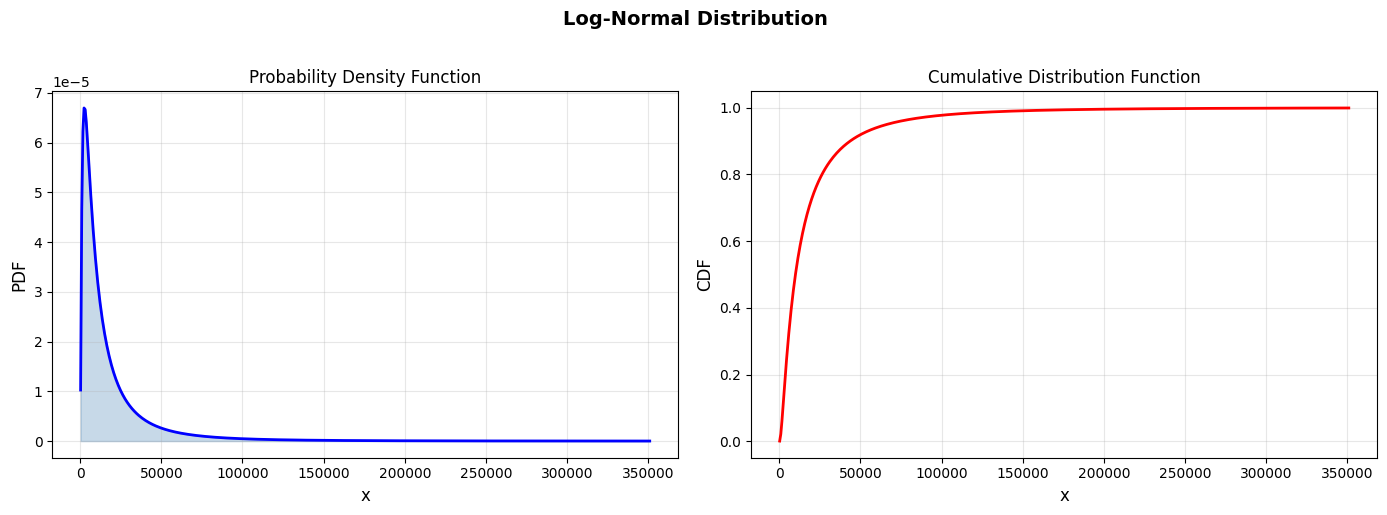

In [4]:
lognormal = LogNormal(4.0, 0.5)

print_statistics(lognormal, "LogNormal(4.0, 0.5)")
plot_distribution(lognormal, title="Log-Normal Distribution")

### Generalized Extreme Value (GEV)
The Generalized Extreme Value distribution unifies three classical extreme value distributions into a single three-parameter family [[2]](#2). It is the limiting distribution for block maxima (e.g., annual maximum floods, peak wind speeds) under very general conditions described by the Fisher-Tippett-Gnedenko theorem.

#### Mathematical Definition

The GEV is parameterized by location $\xi$, scale $\alpha > 0$, and shape $\kappa$. Numerics uses the Hosking parameterization where the sign convention for $\kappa$ follows L-moment theory.

Probability Density Function (PDF):

$$
f(x) = \frac{1}{\alpha} \exp\!\left[-(1-\kappa)y - e^{-y}\right]
$$ 

where the reduced variate $y$ is defined as:

$$
y = \begin{cases}
-\dfrac{1}{\kappa}\ln\!\left(1 - \kappa\dfrac{x - \xi}{\alpha}\right) & \kappa \neq 0 \\[6pt]
\dfrac{x - \xi}{\alpha} & \kappa = 0
\end{cases}
$$

Cumulative Distribution Function (CDF):

$$
F(x) = \exp(-e^{-y})
$$

Inverse CDF (Quantile Function):

$$
Q(p) = \begin{cases}
\xi + \dfrac{\alpha}{\kappa}\left[1 - (-\ln p)^{\kappa}\right] & \kappa \neq 0 \\[6pt]
\xi - \alpha \ln(-\ln p) & \kappa = 0
\end{cases}
$$

Moments (exist when $|\kappa| < 1$ for the mean, $|\kappa| < 1/2$ for the variance):

| Property | Formula ($\kappa \neq 0$) | Formula ($\kappa = 0$, Gumbel) |
|----------|--------------------------|-------------------------------|
| Mean | $\xi + \frac{\alpha}{\kappa}[1 - \Gamma(1+\kappa)]$ | $\xi + \alpha\gamma_E$ |
| Variance | $\frac{\alpha^2}{\kappa^2}[\Gamma(1+2\kappa) - \Gamma^2(1+\kappa)]$ | $\frac{\pi^2}{6}\alpha^2$ |
| Mode | $\xi + \frac{\alpha}{\kappa}[(1+\kappa)^{-\kappa} - 1]$ | $\xi$ |

**When to use:** Modeling extreme events (floods, droughts, maximum/minimum values) [[2]](#2), [[3]](#3)

**Parameters:** $\xi$ (location), $\alpha$ (scale), $\kappa$ (shape)

- $\kappa$ < 0: Weibull (bounded above)
- $\kappa$ = 0: Gumbel (unbounded)
- $\kappa$ > 0: Frechet (heavy-tailed)

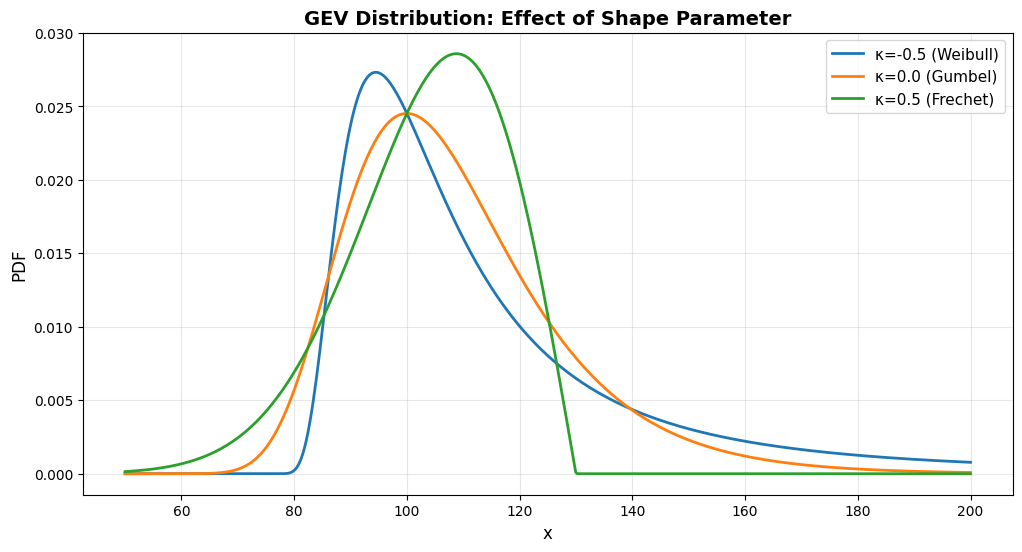


GEV (Frechet type) Statistics:


,Statistic,Value
0,Mean,103.4132
1,Std Deviation,NaN
2,Variance,NaN
3,Skewness,NaN
4,Kurtosis,NaN
5,Minimum,-inf
6,Maximum,130.0000
7,5th Percentile,78.0754
8,Median,105.0234
9,95th Percentile,123.2056



GEV (Gumbel type) Statistics:


,Statistic,Value
0,Mean,108.6582
1,Std Deviation,19.2382
2,Variance,370.1102
3,Skewness,1.1396
4,Kurtosis,5.4000
5,Minimum,-inf
6,Maximum,inf
7,5th Percentile,83.5422
8,Median,105.4977
9,95th Percentile,144.5529



GEV (Weibull type) Statistics:


,Statistic,Value
0,Mean,123.1736
1,Std Deviation,NaN
2,Variance,NaN
3,Skewness,NaN
4,Kurtosis,NaN
5,Minimum,70.0000
6,Maximum,inf
7,5th Percentile,87.3328
8,Median,106.0337
9,95th Percentile,202.4619


In [ ]:
# Create GEV distributions with different shapes
gev_weibull = GeneralizedExtremeValue(100, 15, -0.5)
gev_gumbel = GeneralizedExtremeValue(100, 15, 0.0)
gev_frechet = GeneralizedExtremeValue(100, 15, 0.5)

# Compare shapes
x = np.linspace(50, 200, 500)
plt.figure(figsize=(12, 6))
plt.plot(x, [gev_weibull.PDF(xi) for xi in x], label='κ=-0.5 (Weibull)', linewidth=2)
plt.plot(x, [gev_gumbel.PDF(xi) for xi in x], label='κ=0.0 (Gumbel)', linewidth=2)
plt.plot(x, [gev_frechet.PDF(xi) for xi in x], label='κ=0.5 (Frechet)', linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('PDF', fontsize=12)
plt.title('GEV Distribution: Effect of Shape Parameter', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print_statistics(gev_frechet, "GEV (Frechet type)")
print_statistics(gev_gumbel, "GEV (Gumbel type)")
print_statistics(gev_weibull, "GEV (Weibull type)")

### Gamma
The Gamma distribution is a flexible two-parameter family for modeling positive-valued random variables. It generalizes the Exponential distribution and appears frequently in waiting-time problems, rainfall modeling, and Bayesian statistics. Numerics uses the shape/scale parameterization.

#### Mathematical Definition

Probability Density Function (PDF):

$$
f(x) = \frac{x^{\kappa-1}\, e^{-x/\theta}}{\theta^{\kappa}\,\Gamma(\kappa)}, \quad x > 0
$$

where $\theta > 0$ is the scale parameter and $\kappa > 0$ is the shape parameter. $\Gamma(\cdot)$ is the gamma function.

Cumulative Distribution Function (CDF):

$$
F(x) = \frac{\gamma(\kappa,\, x/\theta)}{\Gamma(\kappa)} = P(\kappa,\, x/\theta)
$$

where $\gamma(\kappa, z)$ is the lower incomplete gamma function and $P(\kappa, z)$ is the regularized lower incomplete gamma function.

Moments:

| Property | Formula |
|----------|---------|
| Mean | $E[X] = \kappa\theta$ |
| Variance | $\text{Var}(X) = \kappa\theta^2$ |
| Skewness | $\gamma_1 = 2/\sqrt{\kappa}$ |
| Kurtosis | $\kappa_4 = 3 + 6/\kappa$ |
| Mode | $(\kappa - 1)\theta$ for $\kappa \geq 1$ |

**Special cases:** When $\kappa$ is a positive integer, the Gamma distribution is also known as the Erlang distribution.

**When to use:** Positive data, waiting times, rainfall amounts [[1]](#1)  

**Parameters:** $\theta$ (scale), $\kappa$ (shape)


Gamma(θ=2, κ=0.5) Statistics:


,Statistic,Value
0,Mean,1.0000
1,Std Deviation,1.4142
2,Variance,2.0000
3,Skewness,2.8284
4,Kurtosis,15.0000
5,Minimum,0.0000
6,Maximum,inf
7,5th Percentile,0.0039
8,Median,0.4549
9,95th Percentile,3.8415


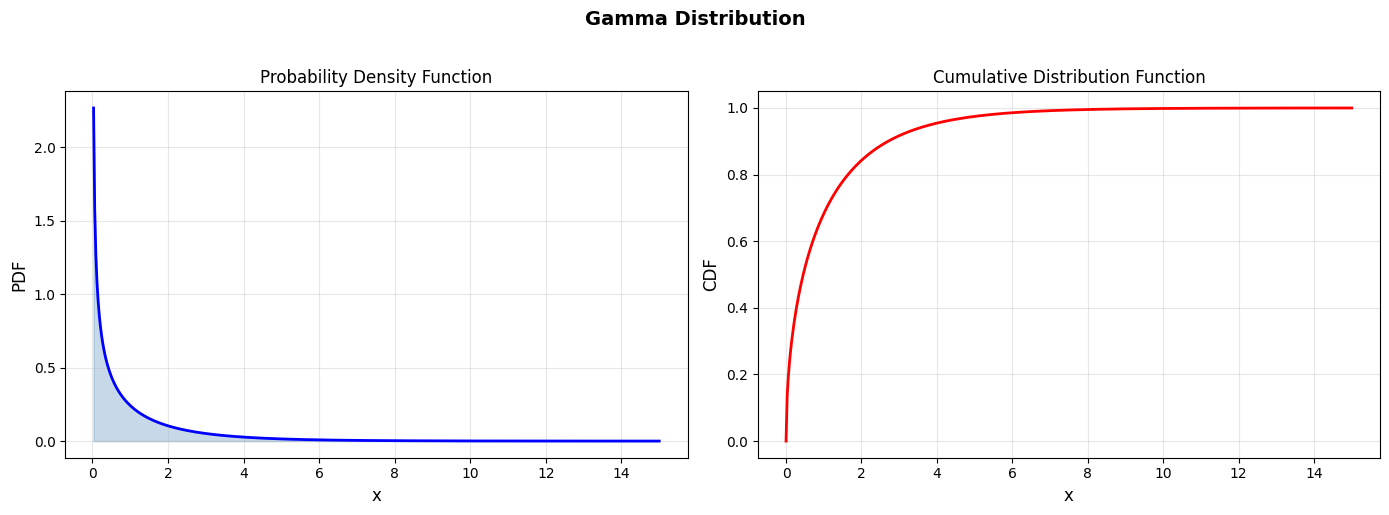

In [6]:
# Gamma distribution
gamma = GammaDistribution(2.0, 0.5)
print_statistics(gamma, "Gamma(θ=2, κ=0.5)")
plot_distribution(gamma, x_range=(0, 15), title="Gamma Distribution")

### Weibull
The Weibull distribution is a flexible two-parameter model for nonnegative data. Its shape parameter controls the failure rate: $\kappa<1$ gives decreasing hazard (early failures), $\kappa=1$ reduces to the Exponential distribution, and $\kappa>1$ yields increasing hazard (wear-out). It is widely used in reliability and wind-speed modeling [[4]](#4), [[5]](#5).

#### Mathematical Definition

Probability Density Function (PDF):

$$
f(x) = \frac{\kappa}{\lambda}\left(\frac{x}{\lambda}\right)^{\kappa-1} \exp\left[-\left(\frac{x}{\lambda}\right)^{\kappa}\right], \quad x \ge 0
$$

Cumulative Distribution Function (CDF):

$$
F(x) = 1 - \exp\left[-\left(\frac{x}{\lambda}\right)^{\kappa}\right]
$$

**When to use:** Reliability analysis, wind speeds, failure times [[4]](#4), [[5]](#5)

**Parameters:** $\lambda$ (scale), $\kappa$ (shape)



Weibull(λ=100, κ=2.5) Statistics:


,Statistic,Value
0,Mean,88.7264
1,Std Deviation,37.9667
2,Variance,1441.4669
3,Skewness,0.3586
4,Kurtosis,2.8568
5,Minimum,0.0000
6,Maximum,inf
7,5th Percentile,30.4807
8,Median,86.3635
9,95th Percentile,155.0962


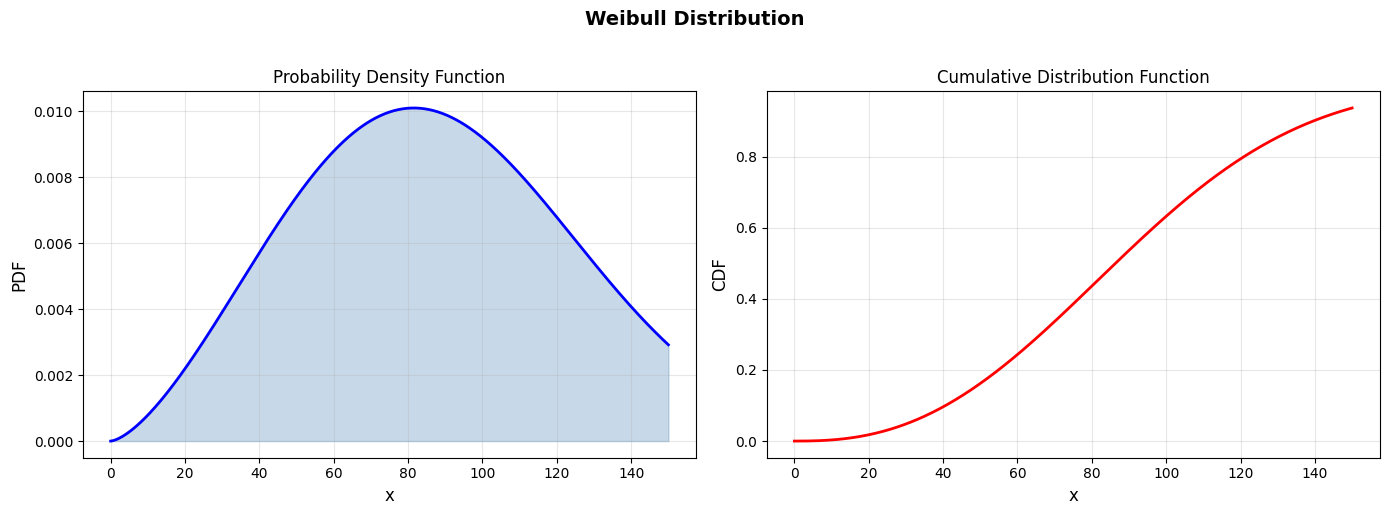

In [7]:
# Weibull distribution
weibull = Weibull(100, 2.5)
print_statistics(weibull, "Weibull(λ=100, κ=2.5)")
plot_distribution(weibull, x_range=(0, 150), title="Weibull Distribution")

### Uniform
The Uniform distribution assigns equal probability density to all values within a bounded interval $[a, b]$. It represents maximum uncertainty (maximum entropy) given only knowledge of the support bounds. It is commonly used as a non-informative prior in Bayesian analysis and for random number generation.

#### Mathematical Definition

Probability Density Function (PDF):

$$
f(x) = \frac{1}{b - a}, \quad a \leq x \leq b
$$

Cumulative Distribution Function (CDF):

$$
F(x) = \frac{x - a}{b - a}, \quad a \leq x \leq b
$$

Inverse CDF (Quantile Function):

$$
Q(p) = a + p(b - a)
$$

Moments:

| Property | Formula |
|----------|---------|
| Mean | $E[X] = \frac{a + b}{2}$ |
| Variance | $\text{Var}(X) = \frac{(b - a)^2}{12}$ |
| Skewness | $\gamma_1 = 0$ |
| Kurtosis | $\kappa = 9/5 = 1.8$ |

**When to use:** Bounded data with no preference for any value  

**Parameters:** min, max


Uniform(0, 100) Statistics:


,Statistic,Value
0,Mean,50.0000
1,Std Deviation,28.8675
2,Variance,833.3333
3,Skewness,0.0000
4,Kurtosis,1.8000
5,Minimum,0.0000
6,Maximum,100.0000
7,5th Percentile,5.0000
8,Median,50.0000
9,95th Percentile,95.0000


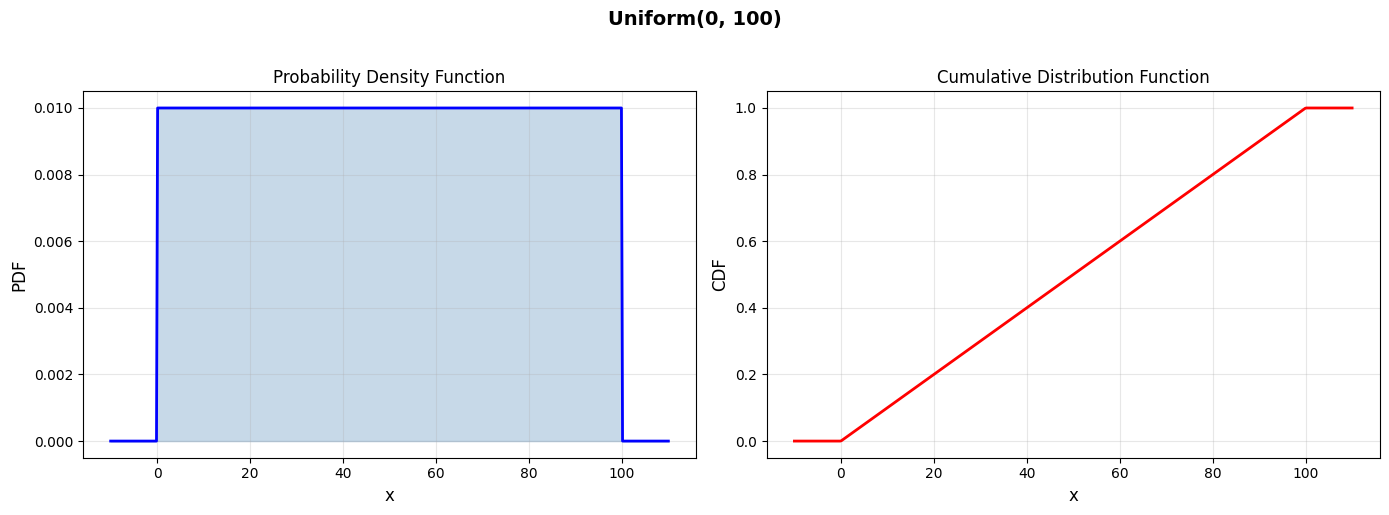

In [8]:
# Uniform distribution
uniform = Uniform(0, 100)
print_statistics(uniform, "Uniform(0, 100)")
plot_distribution(uniform, x_range=(-10, 110), title="Uniform(0, 100)")

### Triangular
The Triangular distribution is defined by three parameters: minimum $a$, mode $c$, and maximum $b$. It provides a simple model for uncertainty when only the range and most likely value are known. It is frequently used in risk assessment, project management (PERT analysis), and expert elicitation.

##### Mathematical Definition

Probability Density Function (PDF):

$$
f(x) = \begin{cases}
\dfrac{2(x - a)}{(b - a)(c - a)} & a \leq x < c \\[6pt]
\dfrac{2}{b - a} & x = c \\[6pt]
\dfrac{2(b - x)}{(b - a)(b - c)} & c < x \leq b
\end{cases}
$$

Cumulative Distribution Function (CDF):

$$
F(x) = \begin{cases}
\dfrac{(x - a)^2}{(b - a)(c - a)} & a \leq x \leq c \\[6pt]
1 - \dfrac{(b - x)^2}{(b - a)(b - c)} & c < x \leq b
\end{cases}
$$

Moments:

| Property | Formula |
|----------|---------|
| Mean | $E[X] = \frac{a + b + c}{3}$ |
| Variance | $\text{Var}(X) = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18}$ |
| Mode | $c$ |

**When to us:** Bounded data with a most likely value (expert opinion)

**Parameters:** min, mode, max


Triangular(0, 30, 100) Statistics:


,Statistic,Value
0,Mean,43.3333
1,Std Deviation,20.9497
2,Variance,438.8889
3,Skewness,0.3561
4,Kurtosis,2.4000
5,Minimum,0.0000
6,Maximum,100.0000
7,5th Percentile,12.2474
8,Median,40.8392
9,95th Percentile,81.2917


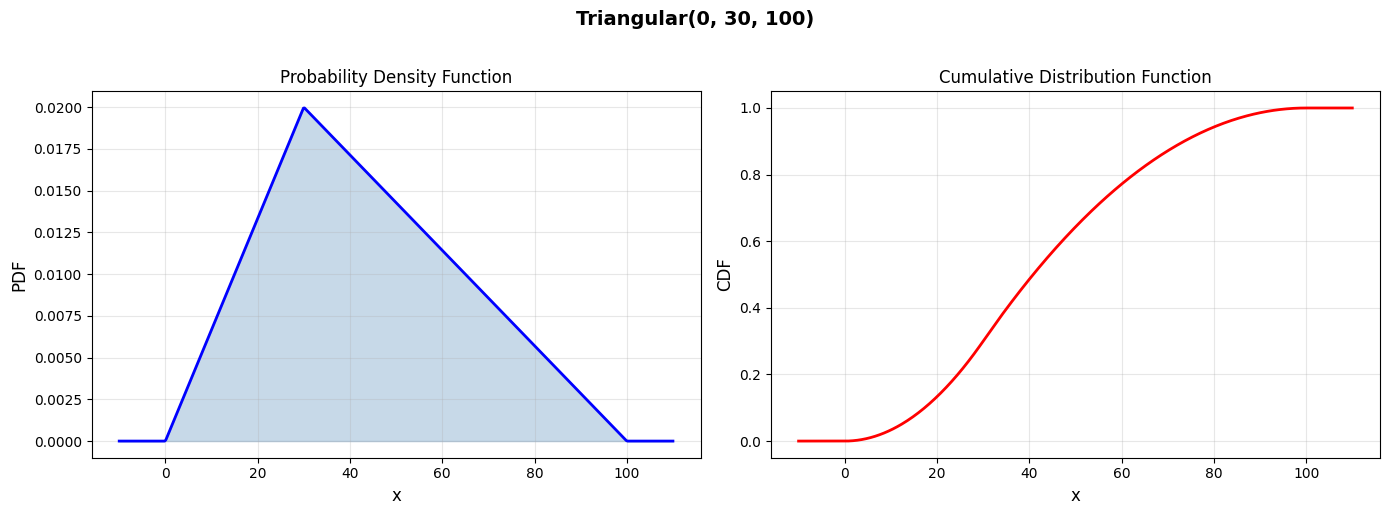

In [9]:
# Triangular distribution
triangular = Triangular(0, 30, 100)
print_statistics(triangular, "Triangular(0, 30, 100)")
plot_distribution(triangular, x_range=(-10, 110), title="Triangular(0, 30, 100)")

### PERT Distribution
The PERT distribution is a smooth, Beta-based alternative to the Triangular distribution for bounded expert-elicited quantities. It uses the same minimum, most-likely, and maximum inputs but yields a smoother density and tails. [[4]](#4)

#### Mathematical Definition
Let $a$ (min), $c$ (mode), and $b$ (max). A common PERT parameterization maps these to a Beta distribution on $[a,b]$ with shape parameters $\alpha,\beta$:
$$
\alpha = 1 + 4\frac{c-a}{b-a}, \quad \beta = 1 + 4\frac{b-c}{b-a}
$$
and the PDF is the scaled Beta density on $[a,b]$. The mean is:
$$
E[X] = \frac{a + 4c + b}{6}
$$

**When to use:** Project planning, expert elicitation (smoother than Triangular) [[4]](#4)

**Parameters:** min, mode, max



PERT(10, 50, 100) Statistics:


,Statistic,Value
0,Mean,51.6667
1,Std Deviation,16.9617
2,Variance,287.6984
3,Skewness,0.0983
4,Kurtosis,2.3462
5,Minimum,10.0000
6,Maximum,100.0000
7,5th Percentile,24.4643
8,Median,51.2732
9,95th Percentile,80.2234


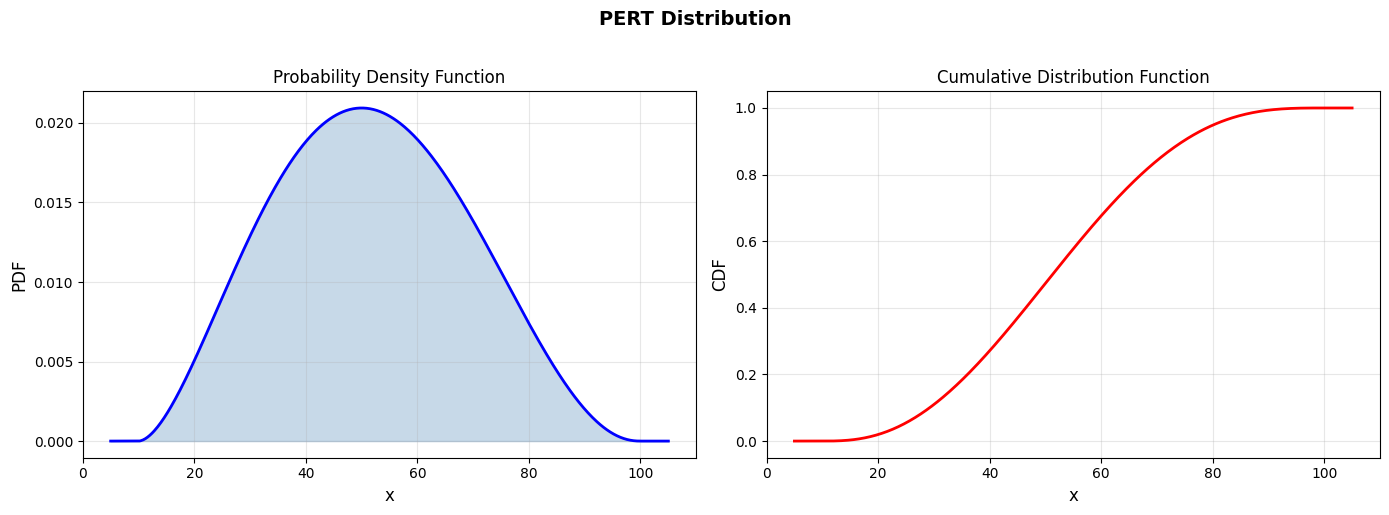

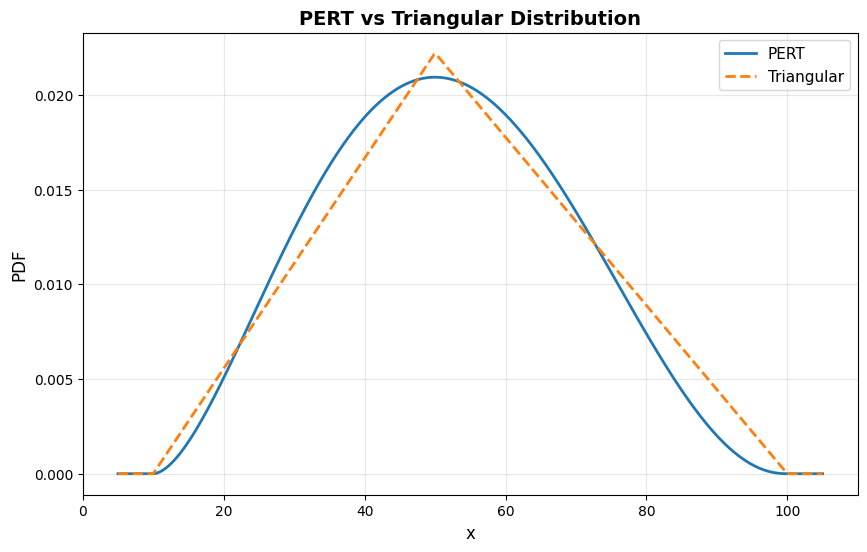

In [10]:
# PERT distribution (smoother version of Triangular)
pert = Pert(10, 50, 100)
print_statistics(pert, "PERT(10, 50, 100)")
plot_distribution(pert, x_range=(5, 105), title="PERT Distribution")

# Compare PERT vs Triangular
tri = Triangular(10, 50, 100)
x = np.linspace(5, 105, 500)
plt.figure(figsize=(10, 6))
plt.plot(x, [pert.PDF(xi) for xi in x], label='PERT', linewidth=2)
plt.plot(x, [tri.PDF(xi) for xi in x], label='Triangular', linewidth=2, linestyle='--')
plt.xlabel('x', fontsize=12)
plt.ylabel('PDF', fontsize=12)
plt.title('PERT vs Triangular Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## Discrete Distributions
Now we will take a look at popular discrete distributions and when to use them.

**Note:** Numerics uses `PDF()` for both continuous and discrete distributions. For discrete distributions, interpret `PDF()` as the PMF.

### Poisson Distribution
The Poisson distribution models counts of events over a fixed interval when events occur independently at a constant average rate. It is the standard model for rare-event counts. [[4]](#4)

#### Mathematical Definition
Probability Mass Function (PMF):
$$
P(X=k) = \frac{\lambda^{k} e^{-\lambda}}{k!}, \quad k = 0,1,2,\ldots
$$
Mean and variance are both $\lambda$.

**When to use:** Count data, events per time period, rare events [[4]](#4)

**Parameters:** $\lambda$ (rate)



Poisson(3.5) Statistics:


,Statistic,Value
0,Mean,3.5000
1,Std Deviation,1.8708
2,Variance,3.5000
3,Skewness,0.5345
4,Kurtosis,3.2857
5,Minimum,0.0000
6,Maximum,inf
7,5th Percentile,1.0000
8,Median,3.0000
9,95th Percentile,7.0000


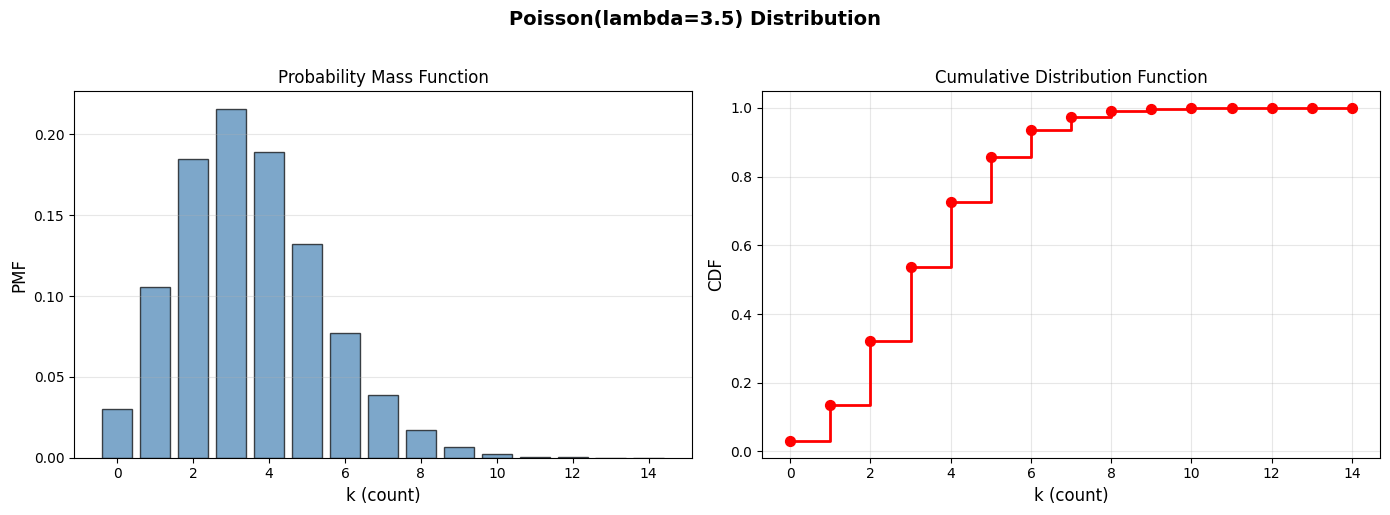

P(X = 3): 0.2158
P(X <= 5): 0.8576


In [11]:
# Poisson distribution
poisson = Poisson(3.5)
print_statistics(poisson, "Poisson(3.5)")

k = np.arange(0, 15)
# Convert to float for compatibility
pmf = [poisson.PDF(float(ki)) for ki in k]  # PDF method works for both continuous and discrete
cdf = [poisson.CDF(float(ki)) for ki in k]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plotting PMF as bars for discrete distribution
ax1.bar(k, pmf, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('k (count)', fontsize=12)
ax1.set_ylabel('PMF', fontsize=12)
ax1.set_title('Probability Mass Function', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

# Plotting CDF as step function for discrete distribution
ax2.step(k, cdf, where='post', linewidth=2, color='red')
ax2.scatter(k, cdf, color='red', s=50, zorder=3)
ax2.set_xlabel('k (count)', fontsize=12)
ax2.set_ylabel('CDF', fontsize=12)
ax2.set_title('Cumulative Distribution Function', fontsize=12)
ax2.grid(True, alpha=0.3)

fig.suptitle('Poisson(lambda=3.5) Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"P(X = 3): {poisson.PDF(3):.4f}")
print(f"P(X <= 5): {poisson.CDF(5):.4f}")

### Binomial Distribution
The Binomial distribution models the number of successes in $n$ independent Bernoulli trials with success probability $p$. [[4]](#4)

#### Mathematical Definition
Probability Mass Function (PMF):
$$
P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0,1,\ldots,n
$$
Mean $E[X]=np$ and variance $\text{Var}(X)=np(1-p)$.

**When to use:** Fixed number of trials, binary outcomes (success/failure) [[4]](#4)

**Parameters:** $n$ (number of trials), $p$ (success probability)



Binomial(p=0.3, n=20) Statistics:


,Statistic,Value
0,Mean,6.0000
1,Std Deviation,2.0494
2,Variance,4.2000
3,Skewness,0.1952
4,Kurtosis,2.9381
5,Minimum,0.0000
6,Maximum,20.0000
7,5th Percentile,3.0000
8,Median,6.0000
9,95th Percentile,9.0000


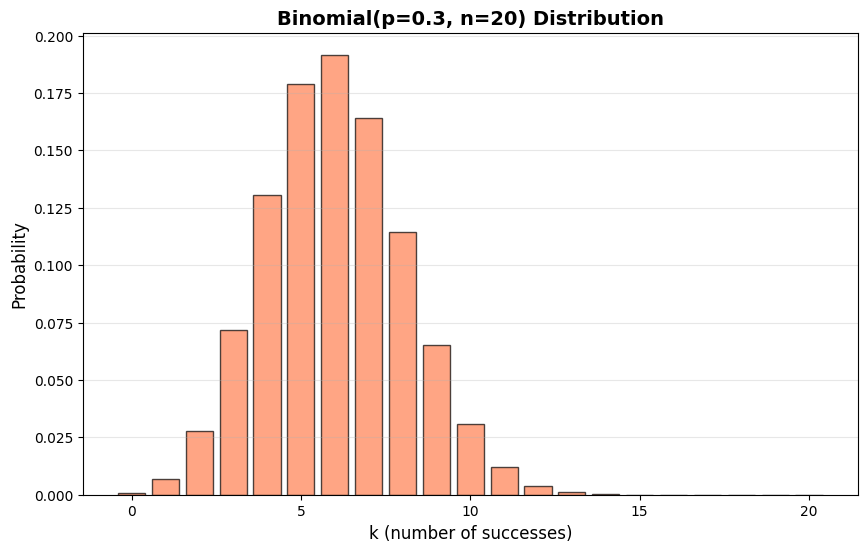

Expected value: 6.00
Most likely value: 6


In [12]:
# Binomial distribution (p=0.3 success probability, n=20 trials)
binomial = Binomial(0.3, 20)
print_statistics(binomial, "Binomial(p=0.3, n=20)")

k = np.arange(0, 21)
# Convert to float for compatibility
pmf = [binomial.PDF(float(ki)) for ki in k]

# Plotting PMF as bars for discrete distribution
plt.figure(figsize=(10, 6))
plt.bar(k, pmf, alpha=0.7, color='coral', edgecolor='black')
plt.xlabel('k (number of successes)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Binomial(p=0.3, n=20) Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print(f"Expected value: {binomial.Mean:.2f}")
print(f"Most likely value: {int(binomial.Mean)}")

## Generating and Analyzing Random Samples

Our univariate distributions (i.e. all the ones in this notebook) have a built in method for generating random samples, GenerateRandomValues(). We use this method below to generate data that is distributed Normal, LogNormal, and Gamma.

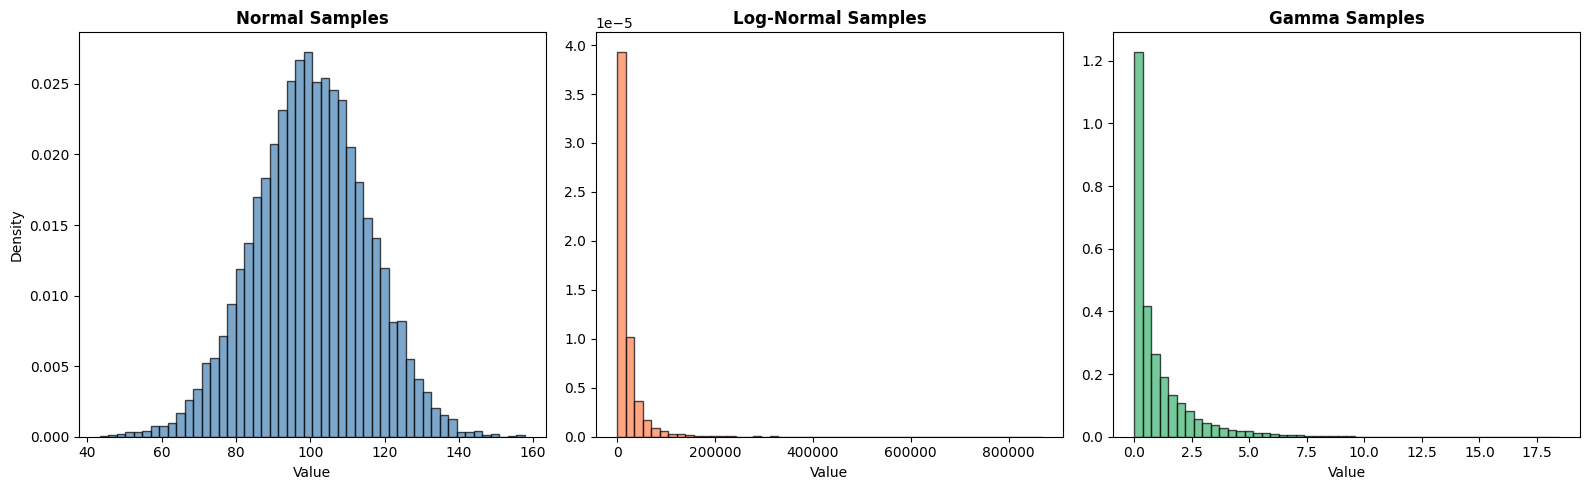


Sample Statistics:


,Distribution,Sample Mean,Sample Std,Sample Skew
0,Normal,100.219901,15.069094,-0.047473
1,Log-Normal,19668.550218,33116.442369,7.482044
2,Gamma,0.995555,1.383793,2.766915


In [13]:
# Generate samples from different distributions
n_samples = 10000

# Convert directly to Python list for ploting
normal_samples = list(Normal(100, 15).GenerateRandomValues(n_samples))
lognormal_samples = list(LogNormal(4, 0.5).GenerateRandomValues(n_samples))
gamma_samples = list(GammaDistribution(2, 0.5).GenerateRandomValues(n_samples))

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(normal_samples, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Normal Samples', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')

axes[1].hist(lognormal_samples, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_title('Log-Normal Samples', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')

axes[2].hist(gamma_samples, bins=50, density=True, alpha=0.7, color='mediumseagreen', edgecolor='black')
axes[2].set_title('Gamma Samples', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()

# Summary statistics
stats_df = pd.DataFrame({
    'Distribution': ['Normal', 'Log-Normal', 'Gamma'],
    'Sample Mean': [np.mean(normal_samples), np.mean(lognormal_samples), np.mean(gamma_samples)],
    'Sample Std': [np.std(normal_samples), np.std(lognormal_samples), np.std(gamma_samples)],
    'Sample Skew': [
        pd.Series(normal_samples).skew(),
        pd.Series(lognormal_samples).skew(),
        pd.Series(gamma_samples).skew()
    ]
})

print("\nSample Statistics:")
display(stats_df)


### Latin Hypercube Sampling
Latin Hypercube Sampling (LHS) is a stratified sampling technique that ensures each dimension is sampled evenly.
This produces better space-filling designs than pure random sampling when the number of samples is limited.

#### How It Works 
Latin Hypercube Sampling divides each dimension's range $[0, 1)$ into $n$ equal strata of width $1/n$, then places exactly one sample in each stratum. For $d$ dimensions with $n$ samples, the $i$-th sample in dimension $j$ is:

$$
x_{ij} = \frac{\pi_j(i) + U_{ij}}{n}, \quad i = 0, \ldots, n-1
$$

where $\pi_j$ is a random permutation of $\lbrace 0, 1, \ldots, n-1\rbrace$ (independent for each dimension) and $U_{ij} \sim \text{Uniform}(0, 1)$. The library's `Median` variant replaces $U_{ij}$ with $0.5$, placing each point at the stratum center.

The key guarantee is marginal stratification: when projected onto any single axis, the $n$ samples fall exactly one per stratum. This eliminates the clustering and gaps that plague simple random sampling. For estimating $E[f(X)]$, the variance of the LHS estimator satisfies:

$$
\text{Var}[\hat{\mu}_{\text{LHS}}] \leq \text{Var}[\hat{\mu}_{\text{MC}}]
$$

with equality only when $f$ is constant within each stratum. In practice, LHS often achieves the same accuracy as simple Monte Carlo with 5–10× fewer samples.

**Properties:**
- Stratified sampling (exactly one sample per stratum in each dimension)
- Variance reduction over simple random sampling
- Two variants: random (within-stratum jitter) and median (stratum centers)
- Most efficient for small to medium sample sizes

**When to use:**
- Monte Carlo simulation with limited computational budget
- Sensitivity analysis
- Calibration with expensive models
- Risk assessment studies

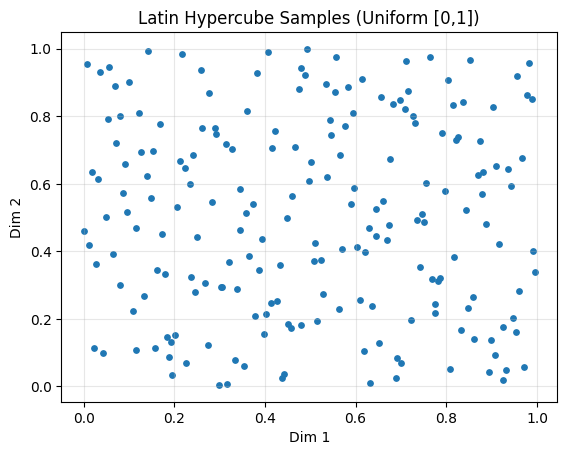

In [14]:
# LHS in [0,1] for each dimension
n_samples = 200
dim = 2
lhs = LatinHypercube.Random(n_samples, dim, seed=12345)

# Convert to numpy for plotting
lhs_np = np.array([[lhs[i, j] for j in range(dim)] for i in range(n_samples)])

plt.scatter(lhs_np[:, 0], lhs_np[:, 1], s=15)
plt.title("Latin Hypercube Samples (Uniform [0,1])")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True, alpha=0.3)
plt.show()

## Comparing Multiple Distributions

Let's compare distributions that might be candidates for the same dataset. More of this is covered in notebook 02, but this is to get you thinking ahead. More than one distribution may fit data well, so it is important to always be considering various distributions for each dataset.

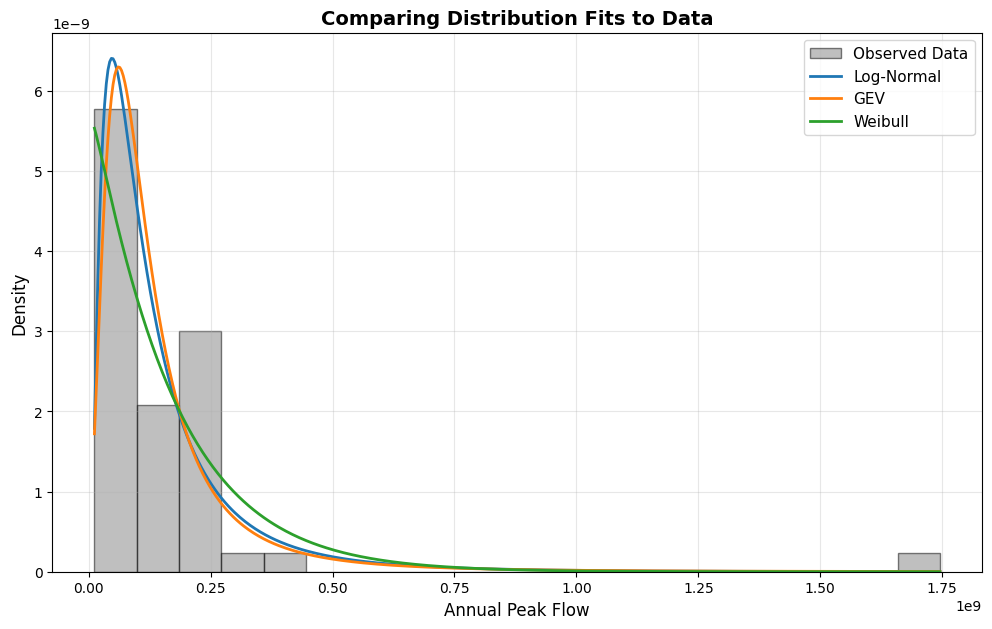


Note: Don't worry about the specifcs of how we fit the data yet. That's in notebook 02.


In [15]:
# Simulate flood frequency data
observed_data = LogNormal(8,0.6).GenerateRandomValues(50, 123)

# Fit the distributions (more in notebook 02)
lognormal_fit = LogNormal()
lognormal_fit.Estimate(observed_data, ParameterEstimationMethod.MaximumLikelihood)

gev_fit = GeneralizedExtremeValue()
gev_fit.Estimate(observed_data, ParameterEstimationMethod.MaximumLikelihood)

weibull_fit = Weibull()
weibull_fit.Estimate(observed_data, ParameterEstimationMethod.MaximumLikelihood)

# Plot comparison
plt.figure(figsize=(12, 7))

# Histogram of observed data
plt.hist(observed_data, bins=20, density=True, alpha=0.5, color='gray', edgecolor='black', label='Observed Data')

# Overlay candidate distributions
x = np.linspace(min(observed_data), max(observed_data), 500)
plt.plot(x, [lognormal_fit.PDF(xi) for xi in x], linewidth=2, label='Log-Normal')
plt.plot(x, [gev_fit.PDF(xi) for xi in x], linewidth=2, label='GEV')
plt.plot(x, [weibull_fit.PDF(xi) for xi in x], linewidth=2, label='Weibull')

plt.xlabel('Annual Peak Flow', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Comparing Distribution Fits to Data', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\nNote: Don't worry about the specifcs of how we fit the data yet. That's in notebook 02.")


## Distribution Selection Guide

|Distribution|Type|Typical Use Case|Parameters|
|---|---|---|---|
|Normal|Continuous|Symmetric data, measurements|$\mu$, $\sigma$|
|Log-Normal|Continuous|Right-skewed positive data|$\mu$, $\sigma$|
|Uniform|Continuous|Equal probability over range|min, max|
|Triangular|Continuous|Bounded with mode|min, mode, max|
|PERT|Continuous|Project estimates|min, mode, max|
|Gamma|Continuous|Positive data, waiting times|$\theta$, $\kappa$|
|Weibull|Continuous|Reliability, failure time|$\lambda$, $\kappa$|
|Exponential|Continuous|Time between events|$\lambda$|
|Gumbel|Continuous|Extreme maxima|$\xi$, $\alpha$|
|GEV|Continuous|General extreme values|$\xi$, $\alpha$, $\kappa$|
|Beta|Continuous|Proportions on [0,1]|$\alpha$, $\beta$|
|Poisson|Discrete|Count data, rare events|$\lambda$|
|Binomial|Discrete|Binary outcomes, trials|$n$, $p$|
|Bernoulli|Discrete|Single trial success/failure|$p$|


## Summary
You've now explored:    

$\checkmark$ Creating distributions with different parameters     
$\checkmark$ Computing PDF, CDF, and quantiles    
$\checkmark$  Generating random samples   
$\checkmark$  Visualizing distributions   
$\checkmark$ Understanding when to use each distribution  

## Exercise

Try creating and plotting these distributions on your own:
1. Beta(2, 5) → useful for probabilities and proportions
2. Student-T(df=3) → heavy-tailed alternative to Normal
3. Chi-Squared(df=5) → goodness-of-fit testing

## References

<a id="1">[1]</a> N. L. Johnson, S. Kotz, and N. Balakrishnan, *Continuous Univariate Distributions*, vols. 1-2, 2nd ed. Wiley, 1994.

<a id="2">[2]</a> S. Coles, *An Introduction to Statistical Modeling of Extreme Values*. Springer, 2001.

<a id="3">[3]</a> Interagency Advisory Committee on Water Data, *Guidelines for Determining Flood Flow Frequency, Bulletin 17C*. U.S. Geological Survey Techniques and Methods, Book 4, Chapter B5, 2018.

<a id="4">[4]</a> U.S. Army Corps of Engineers Risk Management Center, *Numerics Library Documentation: Univariate Distributions*, 2026.

<a id="5">[5]</a> W. Weibull, "A statistical distribution function of wide applicability," *Journal of Applied Mechanics*, vol. 18, no. 3, pp. 293-297, 1951.
